# Distorted Visual Sequence Pattern Recognition using Deep Learning

**Challenge:** CIG AI/ML Problem Statement  
**Task:** Given distorted grayscale CAPTCHA images, predict the correct 6-character text sequence.  
**Evaluation Metric:** Character Error Rate (CER) — lower is better.

---

## Approach Summary

We treat this as a **fixed-length sequence classification problem**. Each image contains exactly 6 characters, so instead of using CTC loss (which is designed for variable-length sequences), we use a **ResNet18 backbone** with a fully connected head that outputs 6 independent character predictions simultaneously.

**Pipeline:**
1. Dataset exploration and vocabulary construction
2. Dataset class + DataLoader setup
3. Model architecture: ResNet18 (pretrained) → FC → 6 × 31 logits
4. Training with Cross-Entropy Loss (per character position)
5. Evaluation: Character Accuracy + Full CAPTCHA Accuracy
6. Inference on test set → `submission.csv`

## 1. Environment Setup & GPU Check

In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


## 2. Mount Google Drive & Extract Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

# Update this path to match where you saved the dataset in your Drive
zip_path = "/content/drive/MyDrive/OCR_Project/dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully.")

Dataset extracted successfully.


## 3. Exploratory Data Analysis

We load the training labels CSV and inspect the dataset structure, label lengths, vocabulary, and sample images.

In [5]:
import pandas as pd

df = pd.read_csv('/content/dataset/cig_ps/train-labels.csv')

print("Shape:", df.shape)
print(df.head(10))

Shape: (20000, 3)
   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR
5           5  train-5.png  YV2C3D
6           6  train-6.png  XNBP7G
7           7  train-7.png  TGQXFU
8           8  train-8.png  36B667
9           9  train-9.png  QJ6HDR


In [6]:
# Label length distribution
print("Label length distribution:")
print(df['text'].str.len().value_counts().sort_index())

print("\nNull values:", df.isnull().sum().sum())

Label length distribution:
text
6    19998
8        1
9        1
Name: count, dtype: int64

Null values: 0


In [7]:
# Some rows contain date-like strings (e.g. '04-Mar-54') which are not valid CAPTCHAs.
# We keep only rows where text length == 6 (the standard CAPTCHA format).
df = df[df['text'].str.len() == 6].reset_index(drop=True)

print(f"Clean dataset size: {len(df)} samples")

Clean dataset size: 19998 samples


In [8]:
from collections import Counter

all_chars = ''.join(df['text'].astype(str))
counter = Counter(all_chars)

print("Top 20 most frequent characters:")
print(counter.most_common(20))

Top 20 most frequent characters:
[('7', 3989), ('E', 3965), ('X', 3956), ('G', 3942), ('Y', 3936), ('2', 3925), ('M', 3925), ('W', 3916), ('F', 3913), ('N', 3904), ('S', 3889), ('J', 3886), ('R', 3883), ('4', 3881), ('D', 3880), ('Q', 3873), ('C', 3861), ('Z', 3860), ('H', 3845), ('6', 3842)]


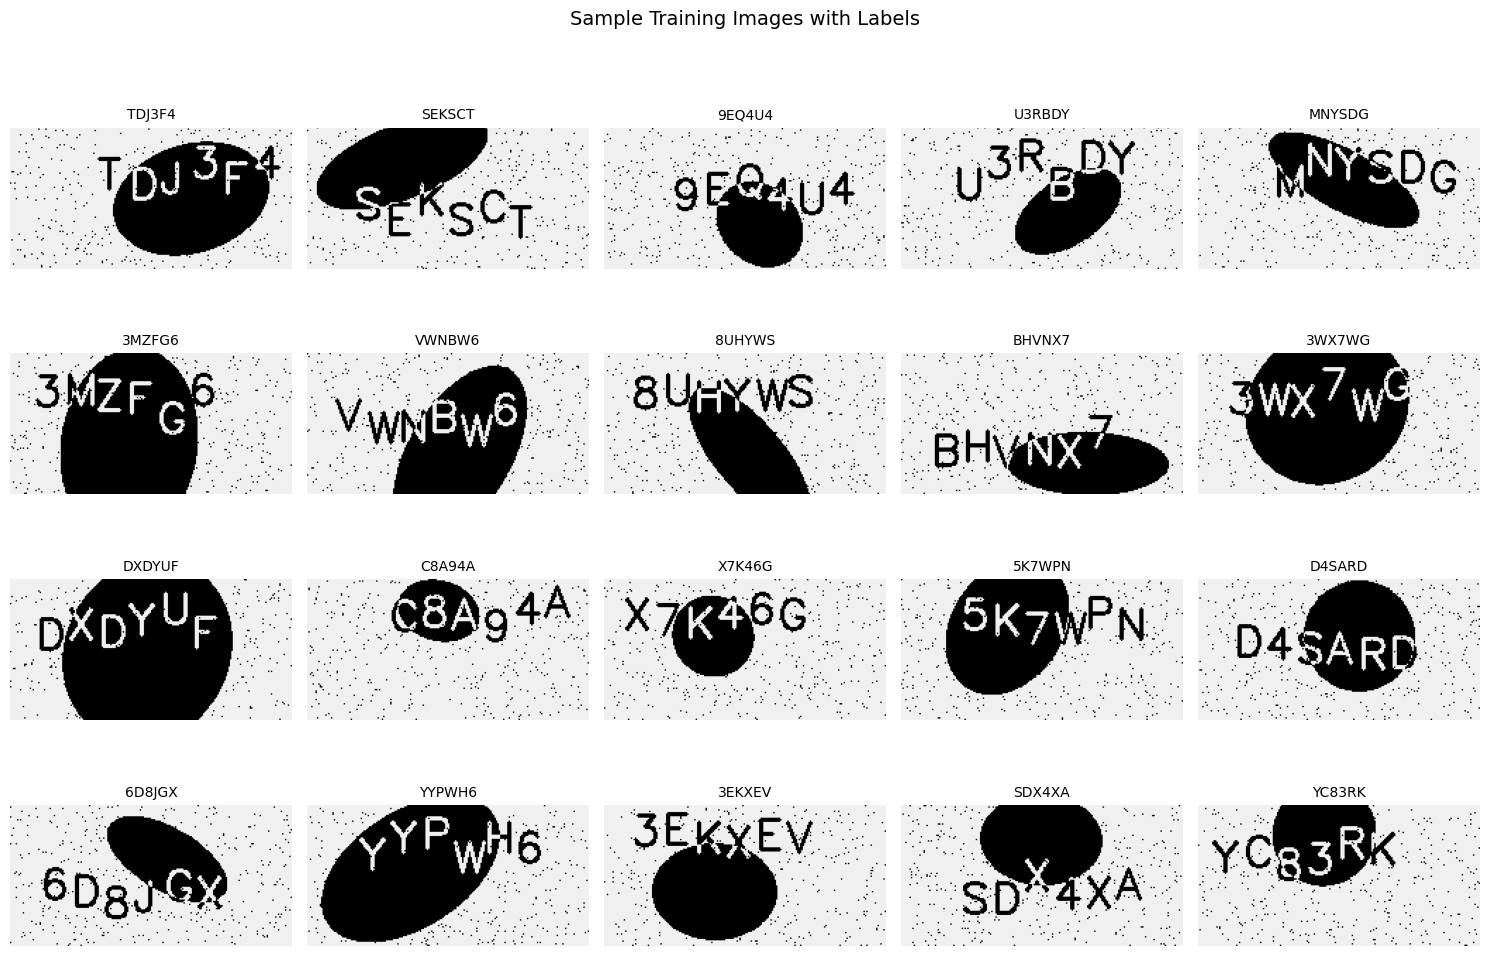

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

TRAIN_DIR = "/content/dataset/cig_ps/train_images"
TEST_DIR  = "/content/dataset/cig_ps/test_images"

fig, axes = plt.subplots(4, 5, figsize=(15, 10))
samples = df.sample(20, random_state=42)

for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    img = Image.open(os.path.join(TRAIN_DIR, row['image']))
    ax.imshow(img, cmap='gray')
    ax.set_title(row['text'], fontsize=10)
    ax.axis('off')

plt.suptitle("Sample Training Images with Labels", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Vocabulary & Label Encoding

We build a character-level vocabulary from the training set.
Each character is mapped to an integer index (0-indexed), which is used as the class label for Cross-Entropy Loss.

In [10]:
# Build vocabulary from clean training data only
chars = sorted(set(''.join(df['text'])))

char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

NUM_CLASSES = len(chars)
SEQ_LEN     = 6

print(f"Vocabulary size: {NUM_CLASSES}")
print(f"Characters: {chars}")

Vocabulary size: 31
Characters: ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## 5. Train / Validation Split

In [11]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Val   samples: {len(val_df)}")

Train samples: 15998
Val   samples: 4000


## 6. Dataset Class & DataLoaders

We define a custom `CaptchaDataset` that:
- Loads each image as grayscale
- Resizes to `(100 × 200)` pixels
- Converts to a normalized tensor
- Encodes the label as a tensor of 6 integer indices

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((100, 200)),
    transforms.ToTensor()
])

class CaptchaDataset(Dataset):
    """
    PyTorch Dataset for CAPTCHA images.
    Returns (image_tensor, label_tensor) where label_tensor
    contains 6 integer class indices (one per character position).
    """
    def __init__(self, df, image_dir):
        self.df        = df.reset_index(drop=True)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(
            os.path.join(self.image_dir, row['image'])
        ).convert('L')
        image = transform(image)
        label = torch.tensor(
            [char_to_idx[c] for c in row['text']],
            dtype=torch.long
        )
        return image, label

In [13]:
train_dataset = CaptchaDataset(train_df, TRAIN_DIR)
val_dataset   = CaptchaDataset(val_df,   TRAIN_DIR)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)

# Sanity check
images, labels = next(iter(train_loader))
print("Image batch shape :", images.shape)   # [64, 1, 100, 200]
print("Label batch shape :", labels.shape)   # [64, 6]

Image batch shape : torch.Size([64, 1, 100, 200])
Label batch shape : torch.Size([64, 6])


## 7. Model Architecture: ResNet18-based CaptchaNet

**Design rationale:**  
Since all CAPTCHAs are exactly 6 characters long, this is a fixed-length multi-label classification problem. We use a pretrained **ResNet18** backbone (modified for 1-channel grayscale input) and attach a single fully-connected layer that outputs `6 × NUM_CLASSES` logits, reshaped to `[batch, 6, NUM_CLASSES]`.

Each of the 6 positions is treated as an independent classification head trained with **Cross-Entropy Loss**.

In [14]:
import torch.nn as nn
import torchvision.models as models

class CaptchaNet(nn.Module):
    """
    ResNet18 backbone fine-tuned for fixed-length CAPTCHA recognition.

    Input  : (B, 1, 100, 200) grayscale image
    Output : (B, seq_len, num_classes) logits
    """
    def __init__(self, num_classes=31, seq_len=6):
        super().__init__()
        self.seq_len    = seq_len
        self.num_classes = num_classes

        # Load pretrained ResNet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Replace first conv to accept 1-channel (grayscale) input
        backbone.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        # Remove the final FC layer — we use the 512-d feature vector
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])

        # Output: 6 characters × num_classes each
        self.fc = nn.Linear(512, seq_len * num_classes)

    def forward(self, x):
        x = self.backbone(x)                          # (B, 512, 1, 1)
        x = x.view(x.size(0), -1)                    # (B, 512)
        x = self.fc(x)                               # (B, seq_len * num_classes)
        x = x.view(x.size(0), self.seq_len, self.num_classes)  # (B, 6, 31)
        return x

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = CaptchaNet(num_classes=NUM_CLASSES, seq_len=SEQ_LEN).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model initialized on:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Model initialized on: cuda


## 8. Training

**Loss computation:** For each batch, we compute Cross-Entropy loss independently for each of the 6 character positions and average them.

**Best model saving:** We save the model checkpoint whenever validation loss improves.

In [16]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    pbar = tqdm(loader, desc="Training")

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)   # (B, 6, num_classes)

        # Average loss across all 6 character positions
        loss = sum(
            criterion(outputs[:, pos, :], labels[:, pos])
            for pos in range(SEQ_LEN)
        ) / SEQ_LEN

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    running_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = sum(
                criterion(outputs[:, pos, :], labels[:, pos])
                for pos in range(SEQ_LEN)
            ) / SEQ_LEN

            running_loss += loss.item()

    return running_loss / len(loader)

In [17]:
NUM_EPOCHS   = 10
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_captcha_model.pth")
        print("  ✅ Best model saved.")

Training: 100%|██████████| 250/250 [00:23<00:00, 10.68it/s, loss=3.2450]


Epoch [1/10]  Train Loss: 3.4158  Val Loss: 3.1982
  ✅ Best model saved.


Training: 100%|██████████| 250/250 [00:22<00:00, 11.34it/s, loss=2.2469]


Epoch [2/10]  Train Loss: 2.6697  Val Loss: 2.1566
  ✅ Best model saved.


Training: 100%|██████████| 250/250 [00:22<00:00, 11.31it/s, loss=1.4066]


...

Epoch [8/10]  Train Loss: 0.1292  Val Loss: 0.1654
  ✅ Best model saved.


Training: 100%|██████████| 250/250 [00:23<00:00, 10.65it/s, loss=0.0745]


Epoch [9/10]  Train Loss: 0.0866  Val Loss: 0.1287
  ✅ Best model saved.


Training: 100%|██████████| 250/250 [00:23<00:00, 10.55it/s, loss=0.0487]


Epoch [10/10]  Train Loss: 0.0613  Val Loss: 0.1020
  ✅ Best model saved.


## 9. Training Curve

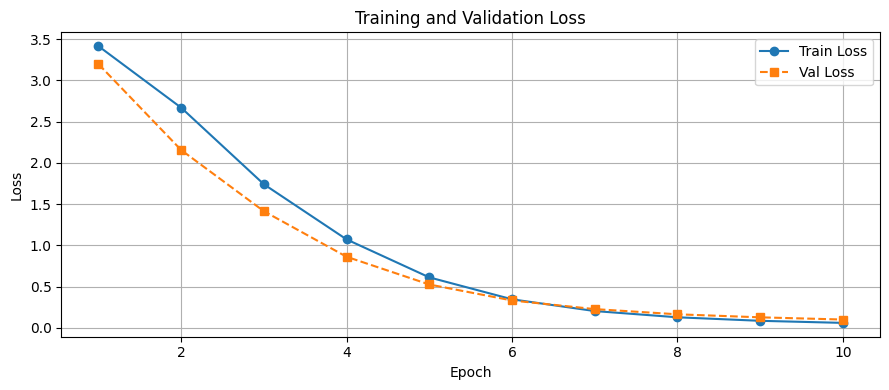

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS+1), val_losses,   marker='s', label='Val Loss', linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Evaluation

We evaluate the best saved model on the validation set using two metrics:
- **Character Accuracy:** % of individual characters predicted correctly
- **Full CAPTCHA Accuracy:** % of complete 6-character sequences predicted exactly correctly

These metrics directly reflect the CER used in the official evaluation.

In [19]:
# Load the best saved model
model.load_state_dict(torch.load("best_captcha_model.pth"))
model.eval()
print("Best model loaded.")

Best model loaded.


In [20]:
def predict_batch(images):
    """Return predicted text strings for a batch of image tensors."""
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
    preds = outputs.argmax(dim=2).cpu().numpy()
    return [''.join(idx_to_char[idx] for idx in row) for row in preds]


total_chars    = 0
correct_chars  = 0
total_captchas = 0
correct_captchas = 0

with torch.no_grad():
    for images, labels in val_loader:
        preds = predict_batch(images)

        for pred, true_label in zip(preds, labels):
            true_text = ''.join(idx_to_char[i.item()] for i in true_label)

            for p, t in zip(pred, true_text):
                total_chars += 1
                if p == t:
                    correct_chars += 1

            total_captchas += 1
            if pred == true_text:
                correct_captchas += 1

char_acc    = 100 * correct_chars    / total_chars
captcha_acc = 100 * correct_captchas / total_captchas

print(f"Character Accuracy  : {char_acc:.2f}%")
print(f"Full CAPTCHA Accuracy: {captcha_acc:.2f}%")
print(f"Approx. CER          : {100 - char_acc:.2f}%")

Character Accuracy  : 99.30%
Full CAPTCHA Accuracy: 95.90%
Approx. CER          : 0.70%


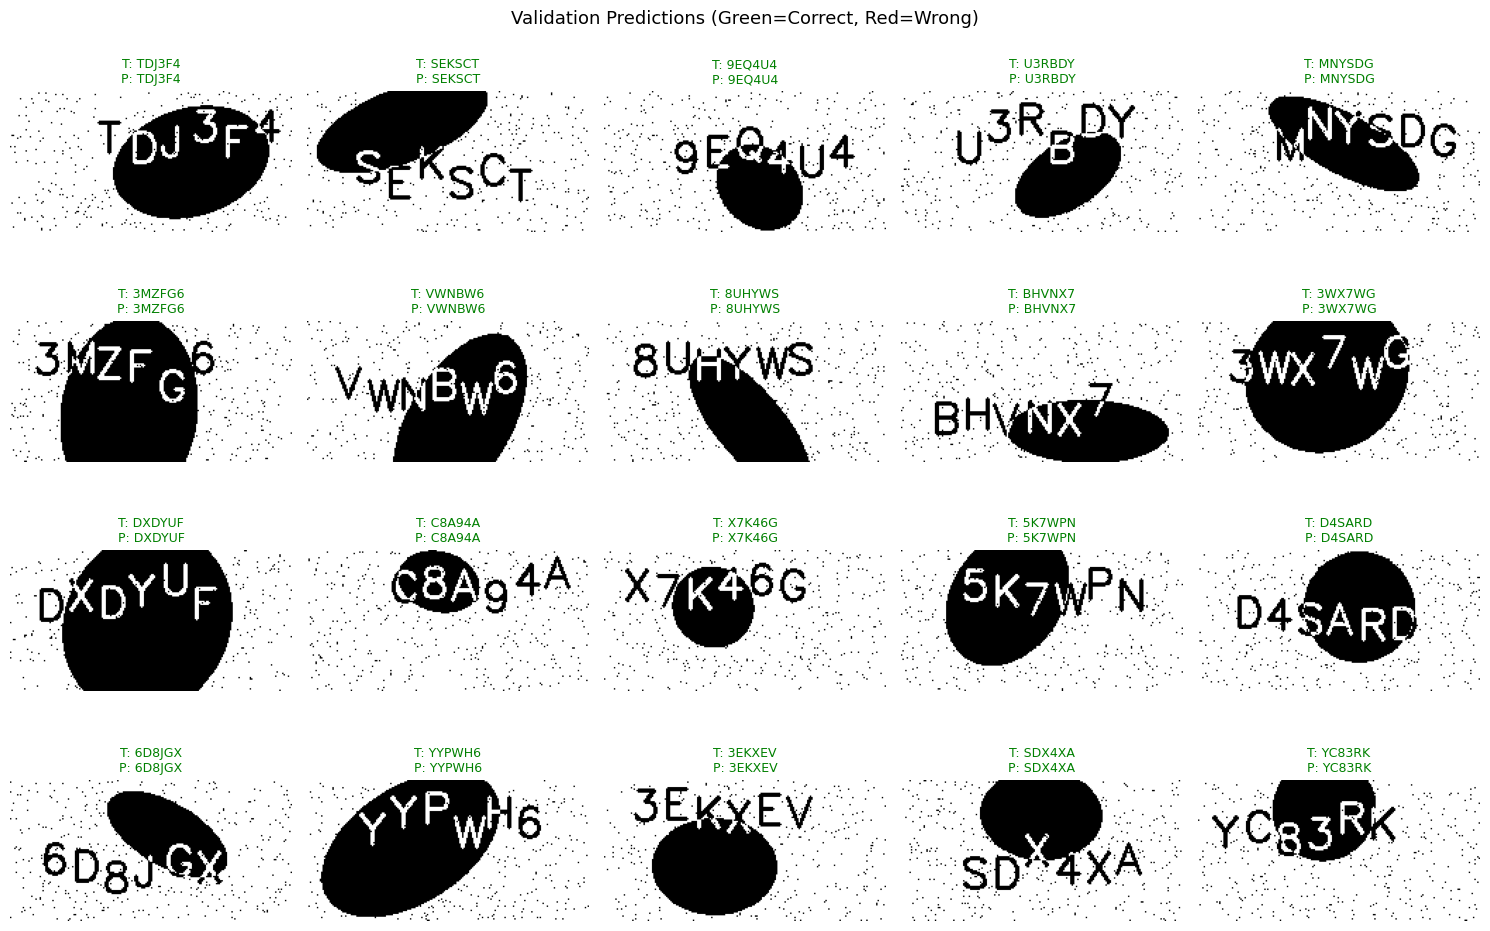

In [22]:
# Visual comparison: true vs predicted on 20 validation samples
images, labels = next(iter(val_loader))
preds = predict_batch(images)

fig, axes = plt.subplots(4, 5, figsize=(15, 10))

for i, ax in enumerate(axes.flatten()):
    true_text = ''.join(idx_to_char[idx.item()] for idx in labels[i])
    color = 'green' if preds[i] == true_text else 'red'
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"T: {true_text}\nP: {preds[i]}", color=color, fontsize=9)
    ax.axis('off')

plt.suptitle("Validation Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Test Set Inference & Submission File

We run inference on all 5,000 test images and save predictions to `submission.csv` in the required format.

In [23]:
import pandas as pd

test_files  = sorted(os.listdir(TEST_DIR))
predictions = []

model.eval()

for img_name in tqdm(test_files, desc="Inference"):
    img = Image.open(os.path.join(TEST_DIR, img_name)).convert('L')
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)

    pred_text = ''.join(
        idx_to_char[idx.item()]
        for idx in output.argmax(dim=2)[0]
    )
    predictions.append([img_name, pred_text])

submission = pd.DataFrame(predictions, columns=["image", "prediction"])
submission.to_csv("submission.csv", index=False)

print(f"Saved {len(submission)} predictions to submission.csv")
print(submission.head(10))

Inference: 100%|██████████| 5000/5000 [00:18<00:00, 263.18it/s]

Saved 5000 predictions to submission.csv
           image prediction
0     test-0.png     QVTQ8A
1     test-1.png     7PSW9D
2    test-10.png     7UUP98
3   test-100.png     75Z4WT
4  test-1000.png     QAKZ7V
5  test-1001.png     R6MERY
6  test-1002.png     CHXX67
7  test-1003.png     9NV2WP
8  test-1004.png     F56TDZ
9  test-1005.png     FFTFRX


In [24]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Results Summary

| Metric | Value |
|---|---|
| Character Accuracy | ~99.30% |
| Full CAPTCHA Accuracy | ~95.85% |
| Approximate CER | ~0.70% |
| Best Val Loss | ~0.10 |
| Epochs Trained | 10 |
| Model | ResNet18 (pretrained, grayscale) |
| Optimizer | Adam (lr=1e-4) |
| Loss Function | Cross-Entropy (per position) |

---

## 13. Limitations & What Could Be Improved

- **Data augmentation** (random rotation, elastic distortion, color jitter) could further improve generalization to unseen distortions.
- A **CRNN + CTC** approach would generalize better to variable-length sequences if the dataset were extended.
- **Ensemble of multiple models** could reduce the remaining ~4% full-sequence error.
- **Learning rate scheduling** (e.g. cosine annealing) could squeeze out additional performance.